In [117]:
import torch

# how to use RNNCell理解RNNCell的尺寸和用法
batch_size = 1  #批量大小
seq_len = 3
input_size = 4
hidden_size = 2
cell = torch.nn.RNNCell(input_size=input_size, hidden_size=hidden_size)
# (seq, batch, features)
dataset = torch.randn(seq_len, batch_size, input_size)  #3维张量
print(dataset)
hidden = torch.zeros(batch_size, hidden_size)
for idx, input in enumerate(dataset):
    print(input)
    print('=' * 20, idx, '=' * 20)
    print('Input size: ', input.shape)
    hidden = cell(input, hidden)
    print('outputs size: ', hidden.shape)
    print(hidden)

tensor([[[ 0.0514, -1.8886, -0.7076, -1.2515]],

        [[-1.0674,  1.0502, -1.2589,  1.5941]],

        [[-0.9104, -0.9840, -1.0453,  0.0204]]])
tensor([[ 0.0514, -1.8886, -0.7076, -1.2515]])
==================== 0 ====================
Input size:  torch.Size([1, 4])
outputs size:  torch.Size([1, 2])
tensor([[-0.9342, -0.7182]], grad_fn=<TanhBackward0>)
tensor([[-1.0674,  1.0502, -1.2589,  1.5941]])
==================== 1 ====================
Input size:  torch.Size([1, 4])
outputs size:  torch.Size([1, 2])
tensor([[-0.8822, -0.6632]], grad_fn=<TanhBackward0>)
tensor([[-0.9104, -0.9840, -1.0453,  0.0204]])
==================== 2 ====================
Input size:  torch.Size([1, 4])
outputs size:  torch.Size([1, 2])
tensor([[-0.9716, -0.6454]], grad_fn=<TanhBackward0>)


In [118]:
import torch

input_size = 2
seq_len = 3
hidden_size = 6
batch_size = 5
cell = torch.nn.RNNCell(input_size=input_size, hidden_size=hidden_size)
datasets = torch.randn(seq_len, batch_size, input_size)
# print(dataset.shape)
# print(dataset)
hidden = torch.zeros(batch_size, hidden_size)
outputs = []
for idx, input in enumerate(datasets):
    # print(input.shape)
    # print(input)
    hidden = cell(input, hidden)
    print('=' * 20, idx, '=' * 20)
    print('Input size: ', input.shape)#(batch_size,input_size)
    print('outputs size: ', hidden.shape)  #outputs的尺寸是(batch_size,hidden_size)
    print('hideen size: ', hidden.shape)  #hidden的尺寸是(batch_size,hidden_size)
    print(hidden)

==================== 0 ====================
Input size:  torch.Size([5, 2])
outputs size:  torch.Size([5, 6])
hideen size:  torch.Size([5, 6])
tensor([[-0.4136,  0.2283,  0.5035,  0.4684, -0.1052, -0.1058],
        [-0.3109, -0.0609,  0.6131,  0.2993, -0.1584,  0.0274],
        [ 0.0110,  0.3353,  0.4993,  0.3374,  0.1040, -0.0486],
        [-0.8386,  0.3428,  0.3815,  0.7339, -0.3430, -0.3135],
        [-0.0203,  0.1389,  0.5709,  0.2580,  0.0220,  0.0209]],
       grad_fn=<TanhBackward0>)
==================== 1 ====================
Input size:  torch.Size([5, 2])
outputs size:  torch.Size([5, 6])
hideen size:  torch.Size([5, 6])
tensor([[ 2.2763e-01, -4.6271e-01,  7.3122e-01,  3.0071e-01, -3.2267e-01,
          1.5299e-01],
        [ 4.4818e-02,  5.3336e-01,  4.0363e-01,  6.3087e-01,  6.2422e-04,
         -3.0205e-01],
        [ 3.3501e-01, -1.6882e-01,  7.5512e-01,  1.4511e-01, -2.0515e-01,
          3.1296e-01],
        [ 5.5223e-01, -8.8780e-02,  4.7762e-01,  6.1980e-01, -5.6934e-

In [119]:
# how to use RNN:理解RNN的尺寸和用法
import torch
input_size = 2
seq_len = 3
hidden_size = 6
batch_size = 5
layer_num=1
cell=torch.nn.RNN(input_size=input_size, hidden_size=hidden_size,num_layers=layer_num)
datasets = torch.randn(seq_len, batch_size, input_size)
outputs, hidden = cell(datasets)
print(outputs.shape)#outputs的尺寸是(seq_len,batch_size,hidden_size)这里的只包含最后一个时刻的输出
print(hidden.shape)#hidden的尺寸是(layer_num,batch_size,hidden_size)#这里是最终时刻的隐藏状态

torch.Size([3, 5, 6])
torch.Size([1, 5, 6])


In [120]:
#用rnncell实现‘hello'--->'oholo'的预测
import torch
import torch.nn.functional as F

words = 'hello'
pre_words = 'lhlol'
def build_dict(words):
    unique_chars = list(dict.fromkeys(words))
    return {char:idx for idx,char in enumerate(unique_chars)}
def word2idx(words):
    return [word_dict[char] for char in words]
#建立字典
dict.fromkeys(words)# 会自动去重并保留顺序：h, e, l, o
unique_chars = list(dict.fromkeys(words))
word_dict = build_dict(words)
idx_to_char = {idx: char for char, idx in word_dict.items()}
print(word_dict)
idx=word2idx(words)
pre_idx=word2idx(pre_words)
print(idx)
print(pre_idx)
def idx2char(idx):
    return word_dict[idx]
# 把idx转化为one-hot向量
idx_tensor = torch.tensor(idx)
print(idx_tensor.shape)
one_hot_tensor = F.one_hot(idx_tensor)
print(one_hot_tensor)
# 加载数据
input_size = len(unique_chars)
hidden_size = input_size
batch_size = 1
inputs = one_hot_tensor.float().view(-1, batch_size, input_size)
print(inputs.shape)
labels = torch.LongTensor(pre_idx).view(-1, batch_size)

{'h': 0, 'e': 1, 'l': 2, 'o': 3}
[0, 1, 2, 2, 3]
[2, 0, 2, 3, 2]
torch.Size([5])
tensor([[1, 0, 0, 0],
        [0, 1, 0, 0],
        [0, 0, 1, 0],
        [0, 0, 1, 0],
        [0, 0, 0, 1]])
torch.Size([5, 1, 4])


In [121]:
#定义模型
class Model(torch.nn.Module):
    def __init__(self, input_size, hidden_size, batch_size):
        super(Model, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.batch_size = batch_size
        self.cell = torch.nn.RNNCell(input_size=self.input_size, hidden_size=self.hidden_size)
    def forward(self, input,hidden):
        hideen = self.cell(input,hidden)
        return hideen
    def init_hidden(self):
        return torch.zeros(self.batch_size, self.hidden_size)
net = Model(input_size=input_size, hidden_size=hidden_size, batch_size=batch_size)

In [122]:
#定义优化器和损失函数
optimizer = torch.optim.Adam(net.parameters(), lr=0.01)
criterion = torch.nn.CrossEntropyLoss()

In [123]:
#训练模型
loss_history = []  # 用于保存每个 epoch 的 loss
acc_history = []   # 用于保存每个 epoch 的准确率
for epoch in range(50):
    loss = 0
    correct_count = 0 # 记录这一轮猜对了好几个字
    total_count = 0   # 记录这一轮总共猜了几个字
    optimizer.zero_grad()
    hidden = net.init_hidden()
    print(f'Epoch {epoch+1} Prediction: ', end='')
    for ins ,label in zip(inputs, labels):
        hidden =net(ins,hidden)
        loss += criterion(hidden, label)
        _,idx=hidden.max(dim=1)#这样取出来的idx是个tensor，需要用item()转化为int，这里的_是省略号，表示不用关心这个值
        print(idx_to_char[idx.item()], end='')
        # --- 统计准确率 ---
        if idx.item() == label.item():
            correct_count += 1
        total_count += 1
 
    loss.backward()
    optimizer.step()
       # 2. 记录数据
    loss_history.append(loss.item())
    acc = correct_count / total_count
    acc_history.append(acc)
    
    print(f', Loss:{loss.item():.4f}, Acc:{acc:.2%}')
    # print(',Epoch:{},Loss:{:.4f}'.format(epoch+1,loss.item()))

Epoch 1 Prediction: lelel, Loss:6.9833, Acc:60.00%
Epoch 2 Prediction: lelel, Loss:6.8350, Acc:60.00%
Epoch 3 Prediction: lelel, Loss:6.6878, Acc:60.00%
Epoch 4 Prediction: lelel, Loss:6.5430, Acc:60.00%
Epoch 5 Prediction: lolel, Loss:6.4017, Acc:60.00%
Epoch 6 Prediction: lolll, Loss:6.2653, Acc:60.00%
Epoch 7 Prediction: lolll, Loss:6.1346, Acc:60.00%
Epoch 8 Prediction: lolll, Loss:6.0099, Acc:60.00%
Epoch 9 Prediction: lolll, Loss:5.8899, Acc:60.00%
Epoch 10 Prediction: lolll, Loss:5.7730, Acc:60.00%
Epoch 11 Prediction: lolll, Loss:5.6583, Acc:60.00%
Epoch 12 Prediction: lolll, Loss:5.5452, Acc:60.00%
Epoch 13 Prediction: lolol, Loss:5.4332, Acc:80.00%
Epoch 14 Prediction: lolol, Loss:5.3216, Acc:80.00%
Epoch 15 Prediction: lolol, Loss:5.2099, Acc:80.00%
Epoch 16 Prediction: lolol, Loss:5.0974, Acc:80.00%
Epoch 17 Prediction: lolol, Loss:4.9836, Acc:80.00%
Epoch 18 Prediction: lolol, Loss:4.8680, Acc:80.00%
Epoch 19 Prediction: lolol, Loss:4.7507, Acc:80.00%
Epoch 20 Prediction: 

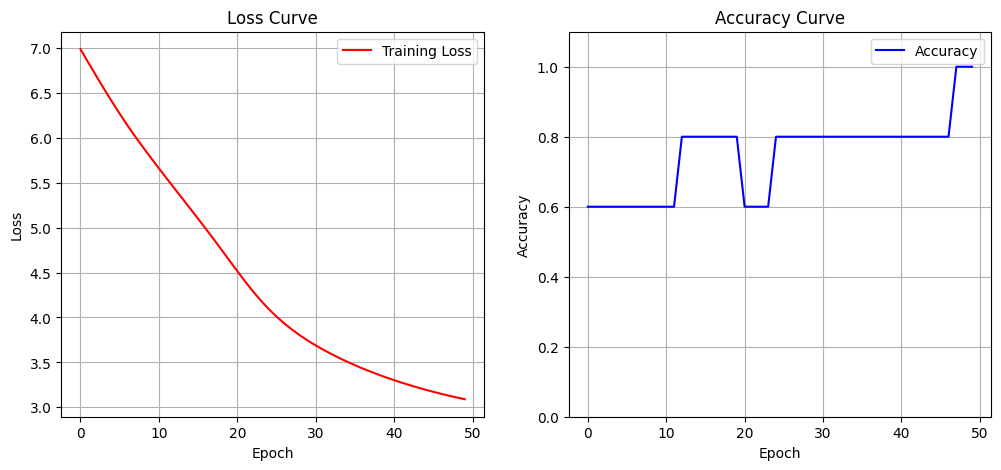

In [124]:
# 开始画图
# -------------------------------------------------------
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5)) # 设置画布大小

# 第一张图：画 Loss (损失率)
plt.subplot(1, 2, 1) # 1行2列，第1张
plt.plot(loss_history, label='Training Loss', color='red')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True) # 显示网格
plt.legend()

# 第二张图：画 Accuracy (准确率)
plt.subplot(1, 2, 2) # 1行2列，第2张
plt.plot(acc_history, label='Accuracy', color='blue')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim(0, 1.1) # 强制Y轴范围在 0~1.1 之间，看得更清楚
plt.grid(True)
plt.legend()

plt.show() # 显示图像